In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the housing dataset
df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_5\Housing.csv')

In [3]:
# 2. Inspect the dataset structure
print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


In [4]:
# 3. Check for any missing values (Cleaning data is always step 1!)
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
# 4. Look at the first few rows
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
# 5. Check the data types
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [7]:
# 1. Define the columns that contain 'yes' and 'no'
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

In [8]:
# 2. Create a function to map 'yes' to 1 and 'no' to 0
def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

# Apply the function to our binary columns
df[binary_columns] = df[binary_columns].apply(binary_map)

In [11]:
# 3. Handle the 'furnishingstatus' column using Dummy Variables
status = pd.get_dummies(df['furnishingstatus'], drop_first=True).astype(int)

# Attach the new numerical columns to our main dataframe
df = pd.concat([df, status], axis=1)

# Drop the old text column since we don't need it anymore
df.drop(['furnishingstatus'], axis=1, inplace=True)

In [12]:
# 4. Check our work!
print("--- Data Types AFTER Encoding ---")
print(df.dtypes)
display(df.head())

--- Data Types AFTER Encoding ---
price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
mainroad           int64
guestroom          int64
basement           int64
hotwaterheating    int64
airconditioning    int64
parking            int64
prefarea           int64
semi-furnished     int32
unfurnished        int32
semi-furnished     int32
unfurnished        int32
dtype: object


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,0,0


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
# 1. Feature Selection: Separate our Target (price) from the Features (everything else)
X = df.drop('price', axis=1) 
y = df['price']

In [15]:
# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} houses")
print(f"Testing data size: {X_test.shape[0]} houses")

Training data size: 436 houses
Testing data size: 109 houses


In [16]:
# 3. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\n✅ Model trained successfully!")


✅ Model trained successfully!


In [17]:
# 4. Make predictions on the test data
predictions = model.predict(X_test)

In [18]:
# 5. Evaluate the model using R-squared (R2)
r2 = r2_score(y_test, predictions)
print(f"\n🏆 R-squared Score: {r2:.4f}")


🏆 R-squared Score: 0.6529


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ajasl\AppData\Local\Temp\ipykernel_8656\2900234627.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
C:\Users\ajasl\AppData\Local\Temp\ipykernel_8656\2900234627.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values_x])


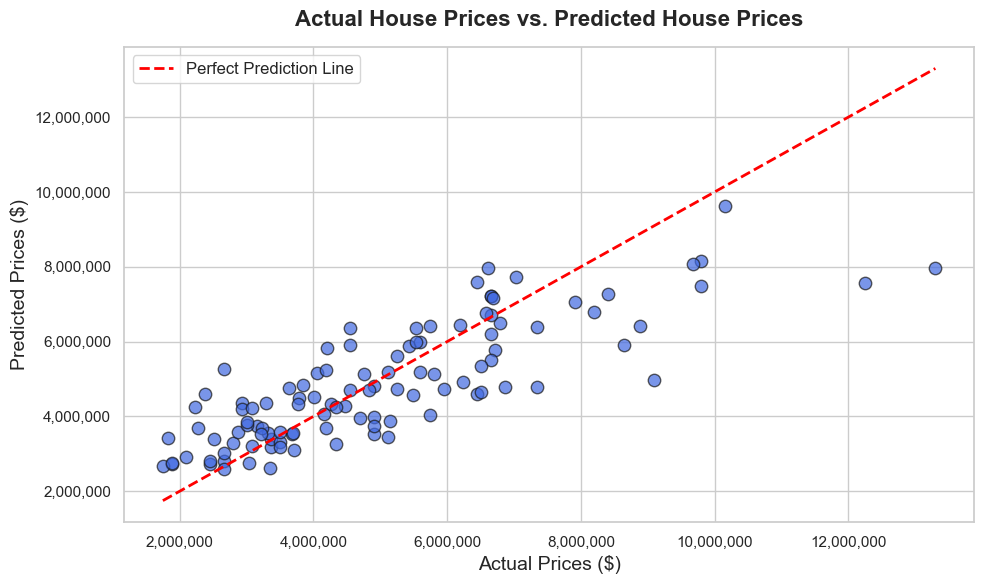

In [21]:
# 1. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Create a scatter plot of Actual vs. Predicted prices
plt.scatter(y_test, predictions, color='royalblue', alpha=0.7, edgecolors='k', s=80)

# 3. Draw the "Perfect Prediction" diagonal line
# (If a house costs 5M and we predict 5M, it lands exactly on this red line)
max_val = max(max(y_test), max(predictions))
min_val = min(min(y_test), min(predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

# 4. Add titles and labels
plt.title('Actual House Prices vs. Predicted House Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Actual Prices ($)', fontsize=14)
plt.ylabel('Predicted Prices ($)', fontsize=14)
plt.legend(fontsize=12)

# 5. Format the axis to show millions clearly (e.g., 5,000,000)
plt.ticklabel_format(style='plain', axis='both')
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
current_values_x = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values_x])

# 6. Show the plot!
plt.tight_layout()
plt.show()